In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

import os
os.chdir("/Users/deweywang/Desktop/GitHub/HEVisum/")


# Training data preparation 

In [5]:
import h5py
import numpy as np
import pandas as pd

# =========================
# 設定
# =========================
image_path = "./dataset/elucidata_ai_challenge_data.h5"
spot_path = "./dataset/elucidata_ai_challenge_data.h5"
group_name = "Test"

cell_prefix = ""   # 例如: "zscore_log2_filtered_"，沒有就留空
output = {}        # 存每個 slide 的結果

# =========================
# 開啟 spot 檔案
# =========================
with h5py.File(spot_path, "r") as f:

    slide_ids = list(f[f"spots/{group_name}"].keys())

    for slide_id in slide_ids:
        print(f"Processing slide: {slide_id}")
        

print("All slides processed.")
output

Processing slide: S_7
All slides processed.


{}

In [3]:
import h5py
import numpy as np
import pandas as pd

# =========================
# 設定
# =========================
image_path = "./dataset/elucidata_ai_challenge_data.h5"
spot_path = "./dataset/elucidata_ai_challenge_data.h5"
group_name = "Train"

cell_prefix = ""   # 例如: "zscore_log2_filtered_"，沒有就留空
output = {}        # 存每個 slide 的結果

# =========================
# 開啟 spot 檔案
# =========================
with h5py.File(spot_path, "r") as f:

    slide_ids = list(f[f"spots/{group_name}"].keys())

    for slide_id in slide_ids:
        print(f"Processing slide: {slide_id}")

        # 讀取 spot table
        df = pd.DataFrame(
            np.array(f[f"spots/{group_name}/{slide_id}"])
        )

        # 找出所有 cell type 欄位
        if cell_prefix:
            cell_cols = [c for c in df.columns if c.startswith(cell_prefix)]
        else:
            # 如果沒有 prefix，你可以改成你自己的規則
            # 例如：只要是 C 開頭
            cell_cols = [c for c in df.columns if c.startswith("C")]

        if len(cell_cols) == 0:
            raise ValueError(f"{slide_id} 沒有找到任何 cell type 欄位")

        # =========================
        # 計算每一個 spot 的 cell type 總和
        # =========================
        df["cell_type_sum"] = df[cell_cols].sum(axis=1)

        # 存起來（你也可以直接存成檔案）
        output[slide_id] = df[["x", "y", "cell_type_sum"]]

print("All slides processed.")
output

Processing slide: S_1
Processing slide: S_2
Processing slide: S_3
Processing slide: S_4
Processing slide: S_5
Processing slide: S_6
All slides processed.


{'S_1':          x     y  cell_type_sum
 0     1554  1297      11.139874
 1      462  1502       9.226409
 2     1488  1548       2.624576
 3     1725  1182      19.530785
 4      581  1113       4.757035
 ...    ...   ...            ...
 2192  1055   701      32.794186
 2193  1225   862      33.371392
 2194   765  1479       0.974102
 2195   607  1525       2.444612
 2196   568  1181       1.045871
 
 [2197 rows x 3 columns],
 'S_2':          x     y  cell_type_sum
 0     1572  1350       4.732073
 1      480  1555       7.626988
 2     1467   526       2.725282
 3      349  1189      11.003961
 4      401  1280       0.481132
 ...    ...   ...            ...
 2265   783   708       6.659100
 2266  1072   754       2.612792
 2267  1243   915      23.876670
 2268   783  1532       6.356908
 2269   625  1578       4.567196
 
 [2270 rows x 3 columns],
 'S_3':         x     y  cell_type_sum
 0    1191   942       2.243283
 1    1037  1165       4.455024
 2     882  1388       2.172176
 3 

In [5]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import math


def plot_cell_expression_all_slides(
    cell_short_name='C17',
    cell_prefix='zscore_log2_filtered_',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/processed_train_spots.h5",
    group_name="log2_Train"
):
    full_col_name = cell_prefix + cell_short_name

    with h5py.File(image_path, "r") as img_h5, h5py.File(spot_path, "r") as spot_h5:
        train_images = img_h5["images/Train"]
        train_spots = spot_h5[f"spots/{group_name}"]
        slide_ids = list(train_spots.keys())

        n = len(slide_ids)
        cols = 3
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = axes.flatten()

        for i, slide_id in enumerate(slide_ids):
            df = pd.DataFrame(np.array(train_spots[slide_id]))
            image = np.array(train_images[slide_id])

            if full_col_name not in df.columns:
                print(f"⚠️ {full_col_name} not in {slide_id}, skipping")
                continue

            x = df["x"].values
            y = df["y"].values
            expr = df[full_col_name].values.astype(float)

            # ========= slide-based z-score =========
            median = np.median(expr)
            mad = np.median(np.abs(expr - median)) + 1e-8
            expr_z = (expr - median) / mad


            ax = axes[i]
            ax.imshow(image)
            sc = ax.scatter(
                x, y,
                c=expr_z,
                cmap="plasma",
                s=10,
                alpha=0.8
            )
            ax.set_title(slide_id)
            ax.axis("off")

        # remove unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        fig.subplots_adjust(right=0.92)
        cbar_ax = fig.add_axes([0.94, 0.2, 0.015, 0.6])
        fig.colorbar(sc, cax=cbar_ax, label="Z-score (slide-based)")

        plt.suptitle(
            f"Spatial Distribution of {cell_short_name} (Slide-based Z-score)",
            fontsize=16
        )
        plt.tight_layout(rect=[0, 0, 0.93, 1])
        plt.show()


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_10194/144258721.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 1])


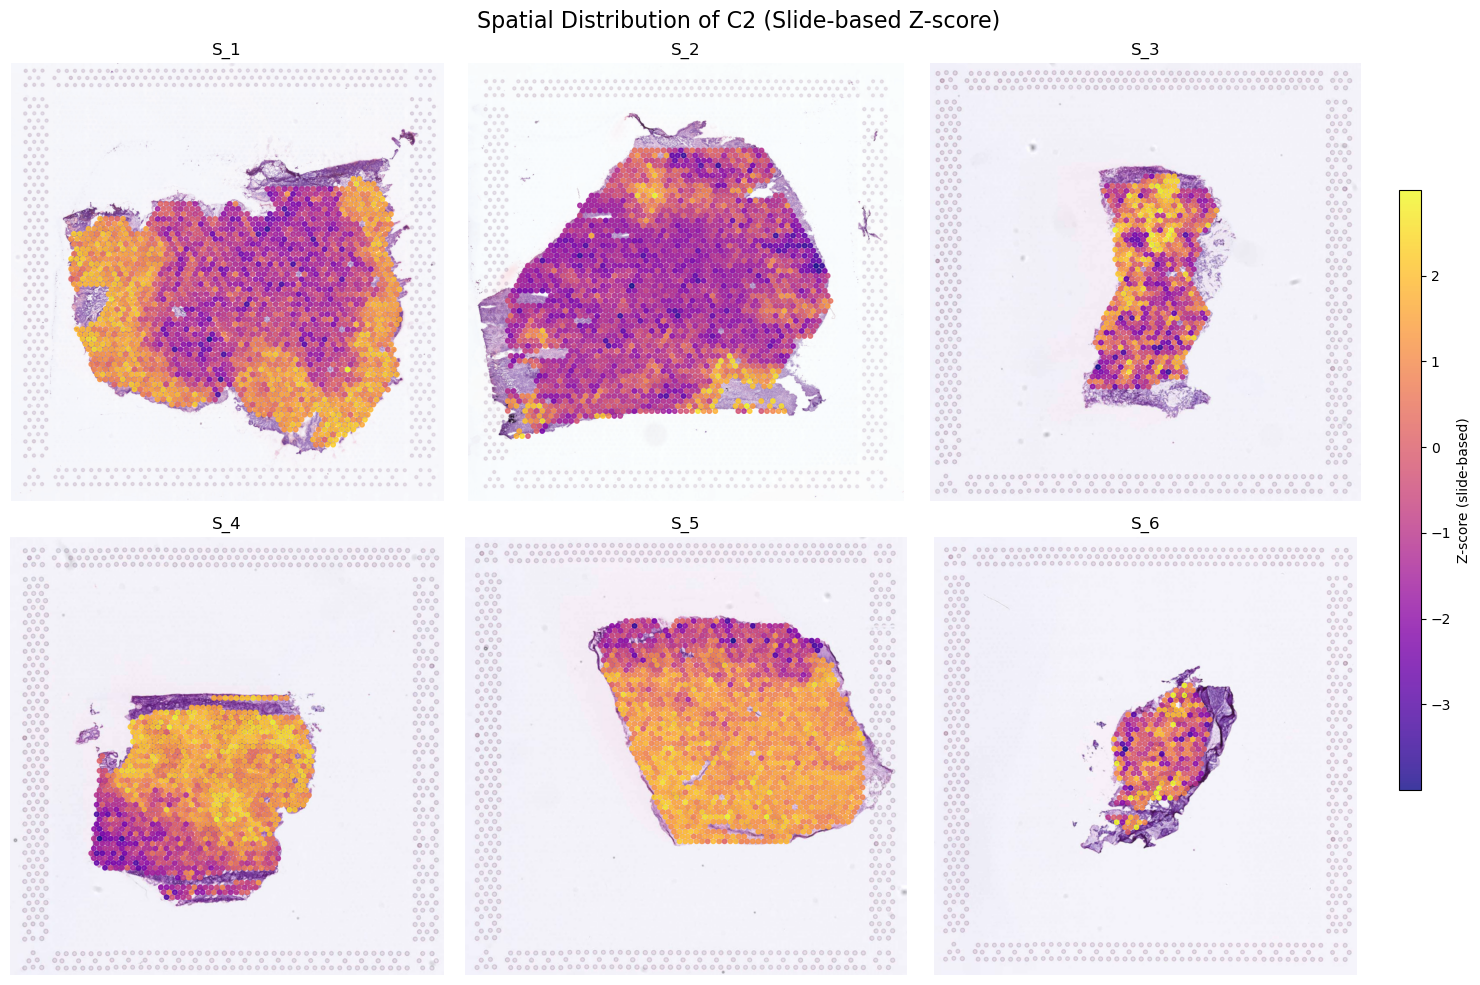

In [6]:
plot_cell_expression_all_slides(
    cell_short_name='C2',
    cell_prefix='rank_',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/try_replace_with_rank.h5",
    group_name="Train"
)

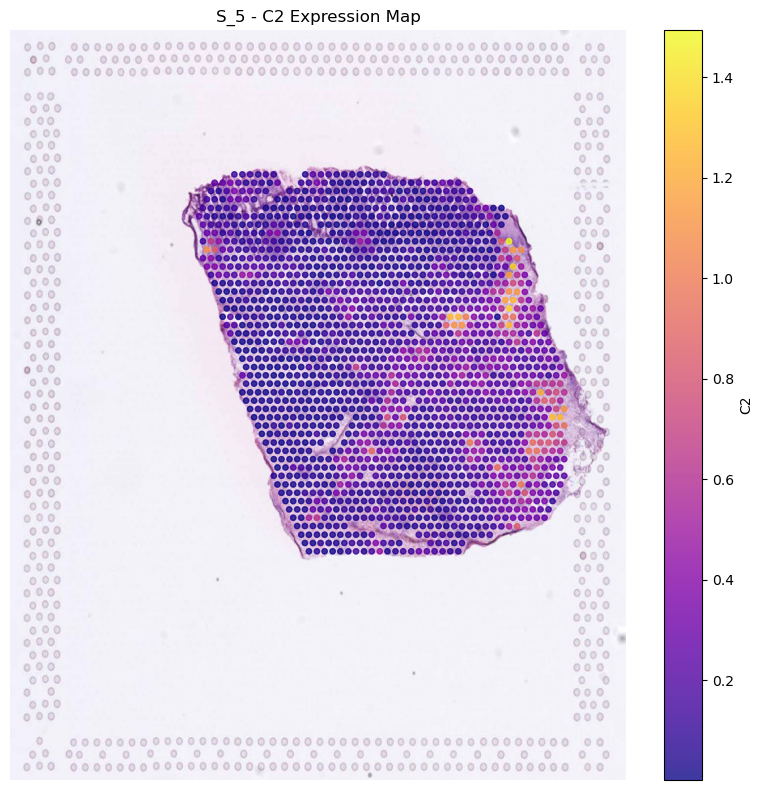

In [7]:

from scripts.plot_expression import plot_cell_expression_on_slide

plot_cell_expression_on_slide(
    slide_id = "S_5",
    cell_type='C2',
    cell_prefix='',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/try_realign.h5",
    group_name="Train"
)

/Users/deweywang/Desktop/GitHub/HEVisum/scripts/plot_expression.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 1])


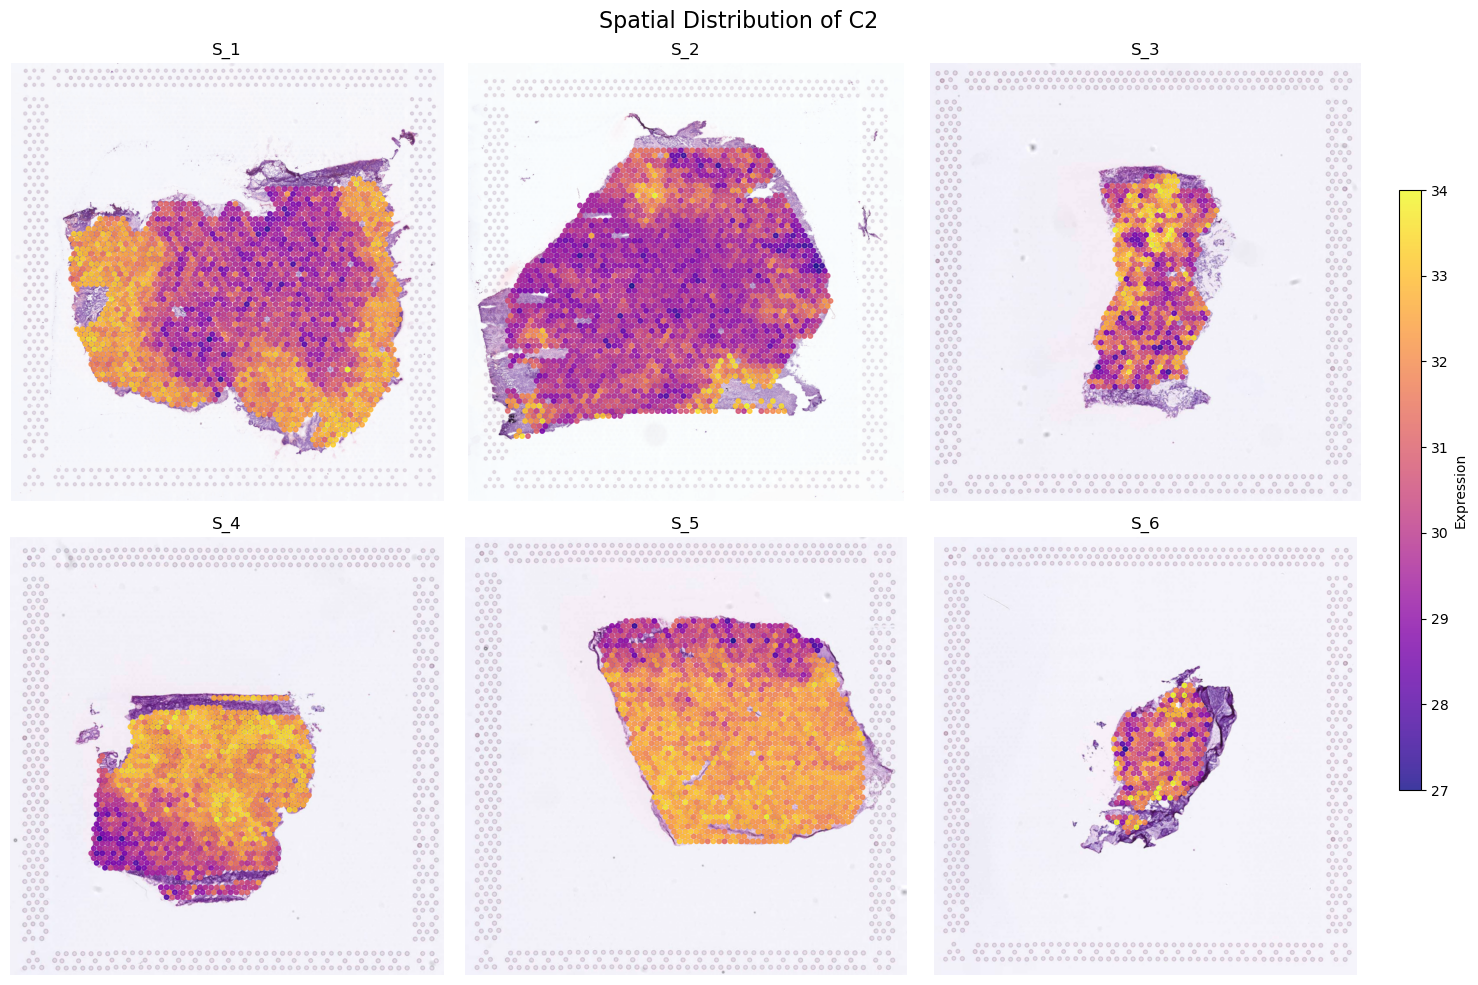

In [8]:
from scripts.plot_expression import plot_cell_expression_all_slides
plot_cell_expression_all_slides(
    cell_short_name='C2',
    cell_prefix='rank_',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/try_replace_with_rank.h5",
    group_name="Train"
)

/Users/deweywang/Desktop/GitHub/HEVisum/scripts/plot_expression.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 1])


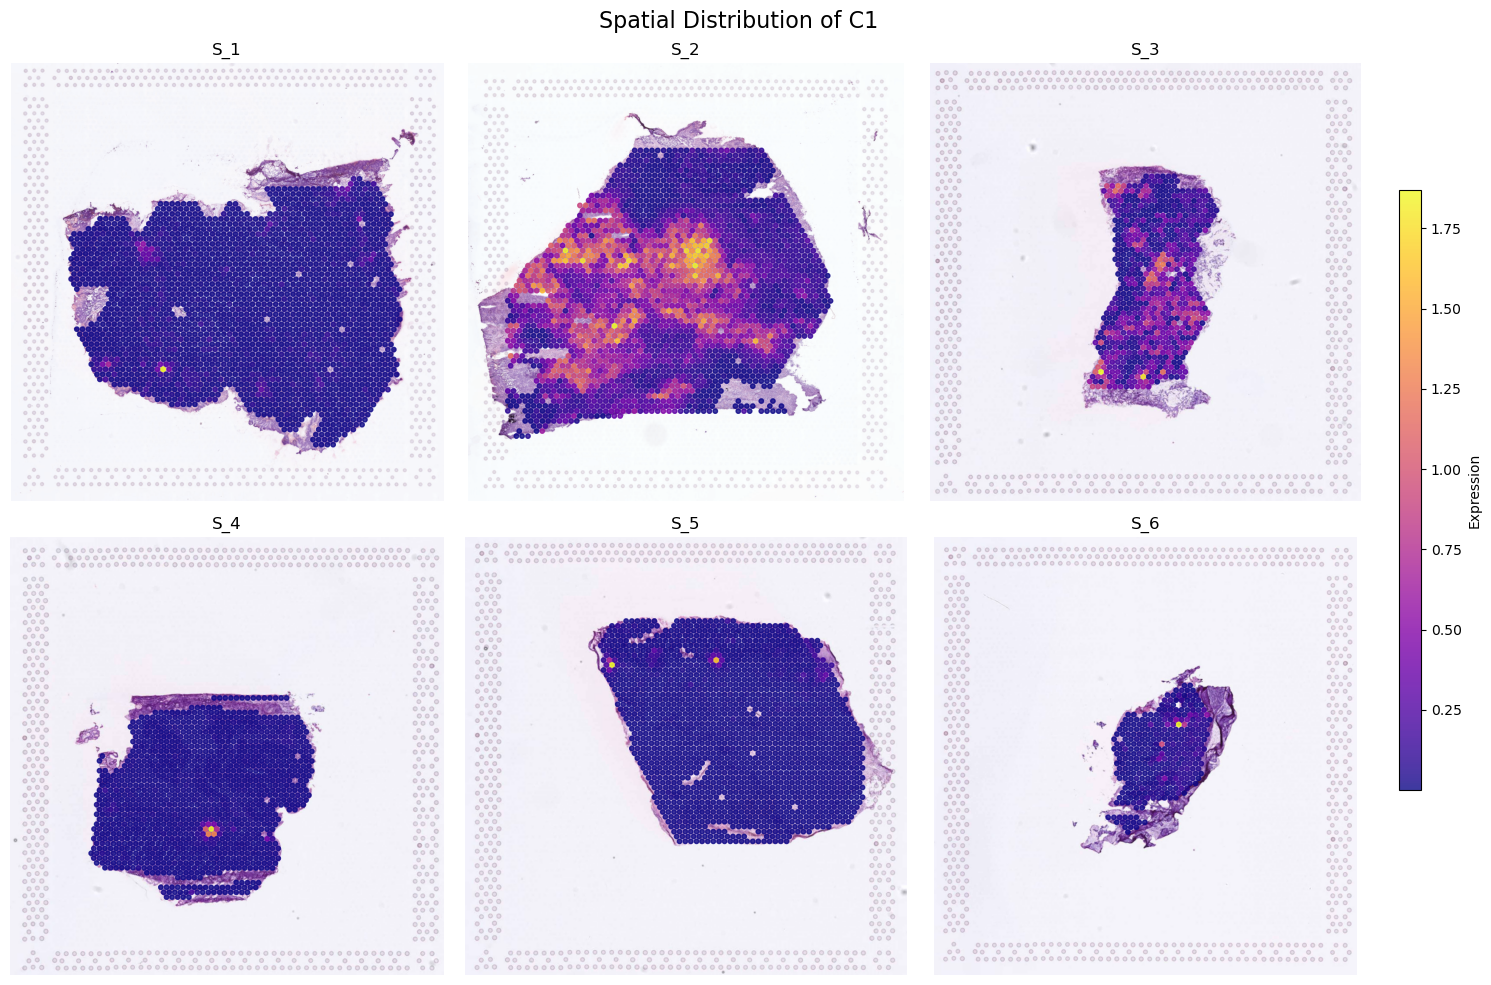

In [2]:
from scripts.plot_expression import plot_cell_expression_all_slides
plot_cell_expression_all_slides(
    cell_short_name='C1',
    cell_prefix='',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/try_realign.h5",
    group_name="Train"
)

In [26]:
def plot_cell_expression_on_slide(
    slide_id,
    cell_type,
    split="Train",   # "Train" or "Test"
    cell_prefix="zscore_log2_filtered_",
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/processed_train_spots.h5",
    submission_csv=None,   # Test 時使用
):
    import h5py
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    assert split in ["Train", "Test"], "split must be 'Train' or 'Test'"

    # ========= 讀取影像 =========
    with h5py.File(image_path, "r") as h5file:
        image = np.array(h5file[f"images/{split}"][slide_id])

    # ========= 讀取 spot 座標 =========
    with h5py.File(spot_path, "r") as f:
        df_spots = pd.DataFrame(
            np.array(f[f"spots/{split}"][slide_id])
        )

    x = df_spots["x"].values
    y = df_spots["y"].values

    # ========= 決定 expression 來源 =========
    if split == "Train":
        full_col_name = (
            cell_type
            if cell_type.startswith(cell_prefix)
            else cell_prefix + cell_type
        )

        if full_col_name not in df_spots.columns:
            raise ValueError(f"Cell type '{full_col_name}' 不存在於該 slide 的資料中！")

        expr = df_spots[full_col_name].values
        expr = expr / 35.0

    else:  # ===== Test =====
        if submission_csv is None:
            raise ValueError("plot Test 時必須提供 submission_csv")

        # 讀 submission
        df_sub = pd.read_csv(submission_csv)

        # cell_type -> C1, C2, ...
        if cell_type.startswith("C"):
            col = cell_type
        else:
            col = cell_type   # 你如果想支援別名，之後可在這裡加 mapping

        if col not in df_sub.columns:
            raise ValueError(f"{col} 不存在於 submission 檔案中")

        # 重要：用 ID 對齊 spot
        df_sub = df_sub.sort_values("ID").reset_index(drop=True)

        if len(df_sub) != len(df_spots):
            raise ValueError("submission 與 test spots 數量不一致，無法對齊")

        expr = df_sub[col].values
        from scipy.stats import rankdata

        expr = rankdata(expr, method="average") - 1
        expr = expr / (len(expr) - 1)

    # ========= 繪圖 =========
    plt.imshow(image, aspect="auto")
    sc = plt.scatter(
        x, y,
        c=expr,
        cmap="plasma",
        s=15,
        alpha=0.8
    )
    plt.colorbar(sc, label=cell_type)
    plt.title(f"{slide_id} - {cell_type} ({split})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


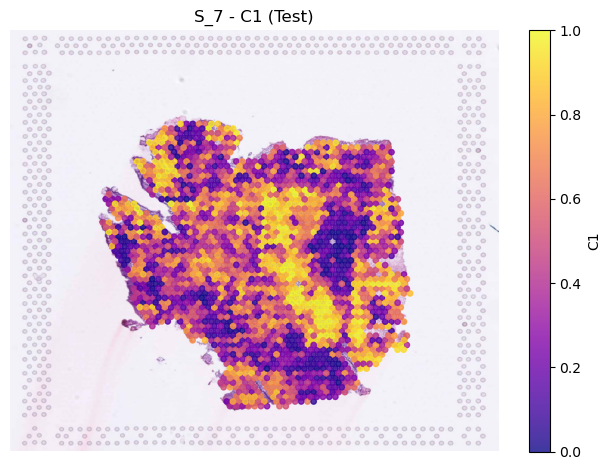

In [33]:
plot_cell_expression_on_slide(
    slide_id="S_7",
    cell_type="C1",
    split="Test",
    cell_prefix="",
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/elucidata_ai_challenge_data.h5",
    submission_csv="/Users/deweywang/Desktop/GitHub/HEVisum/output_folder/tree/submission_fold_mean.csv"
)


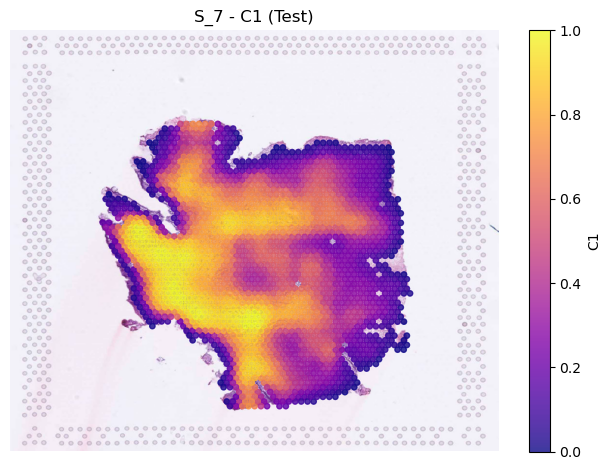

In [28]:
plot_cell_expression_on_slide(
    slide_id="S_7",
    cell_type="C1",
    split="Test",
    cell_prefix="",
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/elucidata_ai_challenge_data.h5",
    submission_csv="output_folder/try_r2/submission_rank_ensemble.csv"
)
